In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Cell 2 — Load processed data
df_scaled = pd.read_csv("../data/processed/cc_segmentation_processed.csv")
print("Shape:", df_scaled.shape)

Shape: (8949, 17)


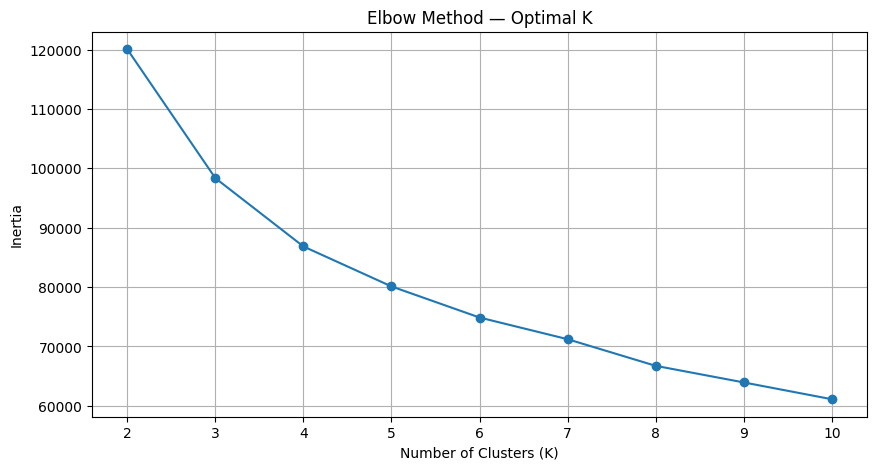

In [3]:
# Cell 3 — Elbow method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method — Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True)
plt.show()

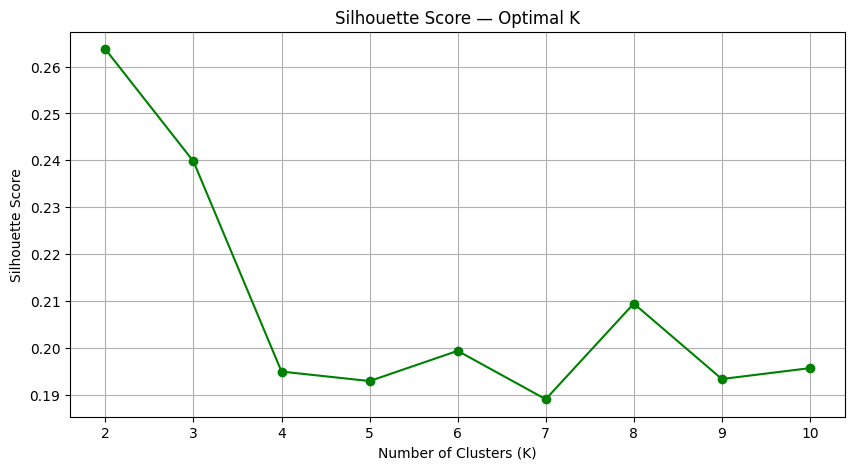

In [4]:
# Cell 4 — Silhouette scores
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score — Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [5]:
# Cell 5 — Print silhouette scores
for k, score in zip(k_range, silhouette_scores):
    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.2637
K=3: Silhouette Score = 0.2398
K=4: Silhouette Score = 0.1950
K=5: Silhouette Score = 0.1930
K=6: Silhouette Score = 0.1994
K=7: Silhouette Score = 0.1891
K=8: Silhouette Score = 0.2095
K=9: Silhouette Score = 0.1934
K=10: Silhouette Score = 0.1957


In [6]:
# Cell 6 — Train final model with K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_scaled["Cluster"] = kmeans_final.fit_predict(df_scaled)
print("Cluster distribution:")
print(df_scaled["Cluster"].value_counts().sort_index())

Cluster distribution:
Cluster
0    1538
1    3544
2    1224
3    2643
Name: count, dtype: int64


In [7]:
# Cell 7 — Save model
import joblib
joblib.dump(kmeans_final, "../models/kmeans_k4.pkl")
print("Model saved.")

Model saved.


In [8]:
# Cell 8 — Save labeled data
df_scaled.to_csv("../data/processed/cc_segmentation_clustered.csv", index=False)
print("Saved clustered data.")

Saved clustered data.
